In [11]:
import numpy as np
import sklearn as sn
import pandas as pd  #Strongly recomend to use pandas 2.2.2, cuz he's compatible with good data wrengler functions! Download Datawrengler
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Downloading all data and creating a data frame

In [12]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

df = pd.read_csv(url)
df.to_csv('medical.csv')
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Lets print all kind of data on each column for understandment of what we're dealing

In [14]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print(80*'=')

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex
['female' 'male']
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765 34

Searching for null data

In [15]:
df.isnull().sum()

# Fortunately there's no null data, which means data collector were amazing at this project

# OBS: Remenber, that's not the standart so we must do this in EVERY project to avoid big problems later

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

# Studing age dsitribuction

In [17]:
print(7*'=','MEAN AGE',7*'=')
print(df['age'].mean())
print(6*'=','MEDIAN AGE',6*'=')
print(df['age'].median())
print(7*'=','MODE AGE',7*'=')
print(df['age'].mode())

======= MEAN AGE =======
39.20702541106129
====== MEDIAN AGE ======
39.0
======= MODE AGE =======
0    18
Name: age, dtype: int64


# Taking percentage of each age by its counts

In [18]:
age_counts = df.age.value_counts()
age_percentage = df.age.value_counts(normalize=True)*100

df_distribution_age = pd.DataFrame({
    'Contagem': age_counts,
    'Porcentagem (%)': age_percentage
})
df_distribution_age.head(5) # Top 5 biggest distribuctions

,Contagem,Porcentagem (%)
age,,
18,69,5.156951
19,68,5.082212
46,29,2.167414
52,29,2.167414
50,29,2.167414


As we can see, Mean and Median values are pretty close at point we can say theres two options:

1) The distribuction is gonna be a constant height of continuous columns

2) The distribuction is gonna be a normal function which the meadian point is the same as mean on graph

* To test this, we're plotting a age counting distribuction to see how it looks!

In [19]:
# By sturges's formulas to determine number of bins (age gap per column in this case)
k = int(1 + 3.322*np.log10(len(df)))
k

# This value 'k' is gonna be used in all graphs, remember him

11

In [20]:
# Plotting data
fig = px.histogram(data_frame=df, 
                   x='age', 
                   marginal='box', 
                   nbins=k, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

# Studying bmi distribuction 

In [21]:
print(7*'=','MEAN AGE',7*'=')
print(df['bmi'].mean())
print(6*'=','MEDIAN AGE',6*'=')
print(df['bmi'].median())
print(7*'=','MODE AGE',7*'=')
print(df['bmi'].mode())

======= MEAN AGE =======
30.66339686098655
====== MEDIAN AGE ======
30.4
======= MODE AGE =======
0    32.3
Name: bmi, dtype: float64


In [22]:
fig1=px.histogram(data_frame=df,
                  x='bmi',
                  marginal='box',
                  nbins=k,
                  color_discrete_sequence=['red'])
fig1.update_layout(bargap=0.1)
fig1.show()

At this time, we see that's a normal distribuction

Observe that there's some 'points' that escapes of box marginal concept of Upper Maginal, it means that we've some exceptions to bmi distribuction. In other words: People with big problems with their body health really above what should be a normal bmi.

Even though plotly graph is interactive, and in certain way it gives us our answer, we can find our parameters in a better route!

In [23]:
df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [24]:
# We must obtain q1 and q3 by our own to find upper and lower marginal

q1 = df.bmi.quantile(0.25)
q3 = df.bmi.quantile(0.75)

print(f'The value of 25% first elements Q1: {q1:.2f} e 75% first elements Q3: {q3:.2f}')

# Calculating the Interquartile Range
iqr = q3 - q1




# Find marginals
lower_marginal = q1 - (1.5 * iqr)
upper_marginal = q3 + (1.5 * iqr)

print(f'The lower marginal is {lower_marginal:.2f} and the upper marginal is {upper_marginal:.2f}')

The value of 25% first elements Q1: 26.30 e 75% first elements Q3: 34.69
The lower marginal is 13.70 and the upper marginal is 47.29


Now, we can caltulate people which is outliers lower and upper. Also, we'll discover people who is below and above the ideal range of bmi

In [25]:
people_bmi_above = len(df[df['bmi']>upper_marginal])
people_bmi_bellow = len(df[df['bmi']<lower_marginal])

print(f'People with bmi above upper marginal: {people_bmi_above}')
print(f'People with bmi bellow lower marginal: {people_bmi_bellow}')

People with bmi above upper marginal: 9
People with bmi bellow lower marginal: 0


Let's see now the values that outliers above upper marginal in BMI

In [26]:
print(27*'=')
print(f'Upper Marginal: {upper_marginal:.2f}')
print(27*'=')
for value in df[df['bmi']>upper_marginal]['bmi']:
    print(value)

Upper Marginal: 47.29
49.06
48.07
47.52
47.41
50.38
47.6
52.58
47.74
53.13


The measurements of body mass index seem to form a [Gaussian distribution](https://en.wikipedia.org/wiki/Normal_distribution) centered around the value 30, with a few outliers towards the right. Here's how BMI values can be interpreted ([source](https://study.com/academy/lesson/what-is-bmi-definition-formula-calculation.html)):

![](https://i.imgur.com/lh23OiY.jpg)

> **EXERCISE**: Can you explain why the distribution of ages forms a uniform distribution while the distribution of BMIs forms a gaussian distribution?
>
> ???

Answer: 

The distribution of BMIs is Gaussian because biological traits influenced by multiple independent factors (genetic and environmental) naturally tend toward a Normal Distribution. A peak at 30 indicates that this is the mean/median of the population, where most individuals are clustered.
On the other hand, the Uniform distribution of ages suggests a controlled sampling process. Instead of representing a natural population pyramid, the researchers likely selected an equal number of participants for each age bracket to ensure balanced representation across the study.

# Are there a relation between smoking and helth charges?

In [ ]:
# How many people smoke and what the percentage?
smokers = len(df[df['smoker']=='yes'])
non_smokers = len(df[df['smoker']=='no'])

print(f'The number of smoker is {smokers} and non-smokers is {non_smokers}')
print(f'Percentual of smokers of data: {(smokers *100/non_smokers):.2f}%')

The number of smoker is 274 and non-smokers is 1064
Percentual of smokers of data: 25.75%


In [ ]:
fig3 = px.histogram(data_frame=df,
                    x='charges',
                    title='Charges x Smoker',
                    color='smoker',
                    nbins=k,
                    color_discrete_sequence=['grey','green'])
fig3.update_layout(bargap=0.1)
fig3.show()


We can make the following observations from the above graph:

* For most customers, the annual medical charges are under \\$10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law"
* There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is \\$7300, the median for smokers is close to \\$35,000.


> **EXERCISE**: Visualize the distribution of medical charges in connection with other factors like "sex" and "region". What do you observe?

In [ ]:
figx1 = px.histogram(data_frame=df,
                     x='charges',
                     y='region',
                     color='sex')
figx1

R: We can see that the 'sex' which have more medical expenses is the male in all regions.

In [ ]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [ ]:
fig4 = px.histogram(data_frame=df,
                    x='smoker',
                    title='Count x Smoker',
                    color='sex',
                    color_discrete_sequence=['green', 'gray'])
fig4

> **EXERCISE**: Visualize the distributions of the "sex", "region" and "children" columns and report your observations. 

In [ ]:
figx2 = px.histogram(data_frame=df,
                     x='children',
                     y='region',
                     color='sex',
                    )
figx2.show()

R: Well, it seems that we've pratically the same concetration of children in SW, SE and NW, with a 'not that much minor' counts of kids in NE, though, NE stills being the only one that its below 350k counts of children of them all. We can see that the 'sex distribution' is practely the same in each region and in all regions there're more boys than girls.

In [ ]:
fig5 = px.scatter(data_frame=df,
                  y='charges',
                  x='age',
                  hover_data='sex',
                  title='Charges x Age',
                  color='smoker',
                  color_discrete_sequence=['orange','green'])
fig5

We can make the following observations from the above chart:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.


* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

     1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
     
     2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
     
     3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.
     

> **EXERCISE**: What other inferences can you draw from the above chart?
>
> ???

1. In the first observation, we can see that the biggest part of "healthy non-smoke" on the graphic pays less than $20k/y independent of their age. Also, every 'healthy non-smoker' person pays less than $40k/y and considering that its minimal the counts of this group paying medical charges between $30k/y-$40k/y we can easily say that: "If don't smoke, you'll ceartainly pays less than $35k/y in medical charges". But, if you do. Well, then its very possible that'll pay way more than $30k/y based on data.

2. Taking another vision on the 'healthy-non smoker' people, we can see basically a linear function on the mainly concentration of them, which is progressive at the way the ages increase. We can also see soemthing like that on 'smokers' but not soo clean like the other one.


In [ ]:
fig6 = px.scatter(data_frame=df,
                  y='charges',
                  x='bmi',
                  hover_data='sex',
                  color='smoker',
                  title='Charges x Bmi')
fig6.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

What other insights can you gather from the above graph?

1. It's visible that're a dense mass of 'red' on the bottom of the image while a less 'blue cloud' is above them. That could be explain by saying that simply are more non-smokers than smokers on data. Or, maybe, there's a hot spot correlationated between the weight of people and the use of cigars that decrease this factor on their bodies. And, we also know at these days, that the nicotine have a loss'weight effect derivative of smoking.

> **EXERCISE**: Create some more graphs to visualize how the "charges" column is related to other columns ("children", "sex", "region" and "smoker"). Summarize the insights gathered from these graphs.
>
> *Hint*: Use violin plots (`px.violin`) and bar plots (`sns.barplot`)


In [ ]:
figx3 = px.violin(data_frame=df,
                  x='smoker',
                  y='charges',
                  title='Charges x Smoker',
                  color='sex')
figx3

In [ ]:
figx4 = px.violin(data_frame=df,
                  x='children',
                  y='charges',
                  title='Charges x Children')
figx4

In [ ]:
figx5 = px.violin(data_frame=df,
                  x='region',
                  y='charges',
                  title='Charges x Region',
                  color='sex')
figx5

In [ ]:
figx6 = px.violin(data_frame=df,
                  x='sex',
                  y='charges',
                  title='Charges x Sex',
                  )
figx6

<Axes: xlabel='region', ylabel='charges'>

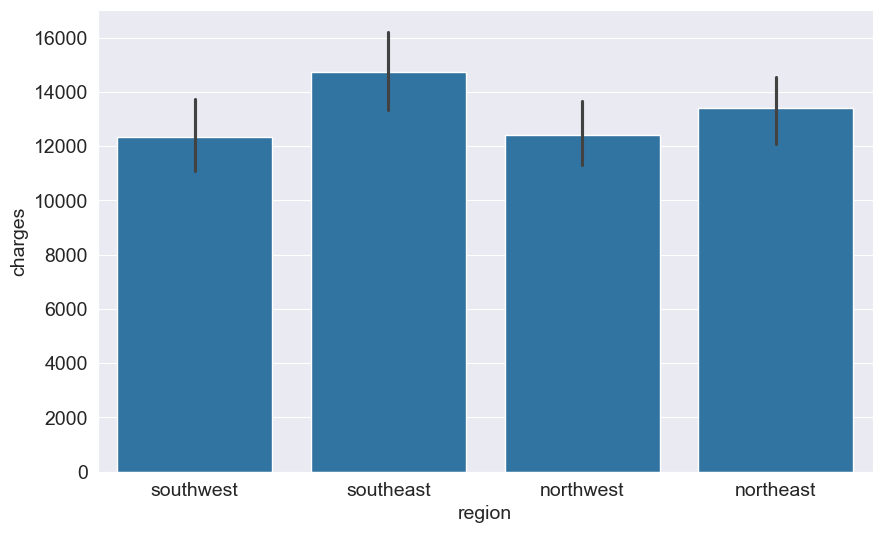

In [ ]:
figx7 = sns.barplot(data=df,
                    x='region',
                    y='charges')
figx7

In [ ]:
figx7 = px.histogram(data_frame=df,
                    x='age',
                    y='charges',
                    nbins=47)
figx7.update_layout(bargap=0.1)
figx7

### Correlation

As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

This relationship is often expressed numerically using a measure called the _correlation coefficient_, which can be computed using the `.corr` method of a Pandas series.

In [ ]:
print(df.charges.corr(df.bmi))

0.19834096883362887


In [ ]:
print(df.charges.corr(df.age))

0.2990081933306478


To compute the correlation for categorical columns, they must first be converted into numeric columns.

In [ ]:
smoker_data = {'yes':1, 'no':0}
smoker_map = df.smoker.map(smoker_data)
smoker_map

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [ ]:
df.charges.corr(smoker_map)

np.float64(0.7872514304984778)

<Axes: xlabel='smoker', ylabel='charges'>

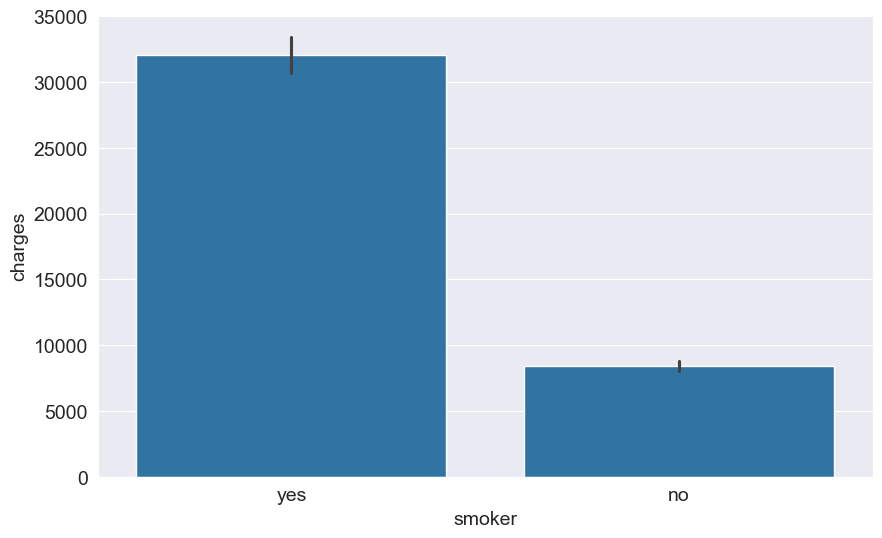

In [ ]:
sns.barplot(data=df,
           x='smoker',
           y ='charges',
           )

In [ ]:
px.violin(data_frame=df,
          x='smoker',
          y='charges')

In [ ]:
px.scatter(data_frame=df,
           y='charges',
           x='age',
           color='smoker',
           )




Here's how correlation coefficients can be interpreted ([source](https://statisticsbyjim.com/basics/correlations)):

* **Strength**: The greater the absolute value of the correlation coefficient, the stronger the relationship.

    * The extreme values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompanied by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won’t see either type of perfect relationship.

    * A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increase or decrease.
    
    * When the value is in-between 0 and +1/-1, there is a relationship, but the points don’t all fall on a line. As r approaches -1 or 1, the strength of the relationship increases and the data points tend to fall closer to a line.


* **Direction**: The sign of the correlation coefficient represents the direction of the relationship.

    * Positive coefficients indicate that when the value of one variable increases, the value of the other variable also tends to increase. Positive relationships produce an upward slope on a scatterplot.
    
    * Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. Negative relationships produce a downward slope.

Here's the same relationship expressed visually ([source](https://www.cuemath.com/data/how-to-calculate-correlation-coefficient/)):

<img src="https://i.imgur.com/3XUpDlw.png" width="360">

The correlation coefficient has the following formula:

<img src="https://i.imgur.com/unapugP.png" width="360">

You can learn more about the mathematical definition and geometric interpretation of correlation here: https://www.youtube.com/watch?v=xZ_z8KWkhXE

Pandas dataframes also provide a `.corr` method to compute the correlation coefficients between all pairs of numeric columns.

### Nota pessoal

No notebook original, ele deixa: 'df.corr()' e o código roda livremente. Porém, não sei se foi
por causa de alguma atualização, isso não funciona mais, pois, o método '.corr' não distingue mais
as colunas OBJECT, ou seja, precisamos retirá-las para que dê certo.

In [ ]:
# Veja
# df.corr()

In [ ]:
df_onlyvalues = pd.read_csv('medical.csv')

In [ ]:
df_onlyvalues.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1338 non-null   int64  
 1   age         1338 non-null   int64  
 2   sex         1338 non-null   object 
 3   bmi         1338 non-null   float64
 4   children    1338 non-null   int64  
 5   smoker      1338 non-null   object 
 6   region      1338 non-null   object 
 7   charges     1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_onlyvalues = df_onlyvalues.select_dtypes(include=numerics)
df_onlyvalues

,Unnamed: 0,age,bmi,children,charges
0,0,19,27.900,0,16884.92400
1,1,18,33.770,1,1725.55230
2,2,28,33.000,3,4449.46200
3,3,33,22.705,0,21984.47061
4,4,32,28.880,0,3866.85520
...,...,...,...,...,...
1333,1333,50,30.970,3,10600.54830
1334,1334,18,31.920,0,2205.98080
1335,1335,18,36.850,0,1629.83350
1336,1336,21,25.800,0,2007.94500


In [ ]:
df_onlyvalues = df_onlyvalues.drop(columns=['Unnamed: 0'], axis=1)
df_onlyvalues

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [ ]:
# Agora sim!!!!
df_onlyvalues.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

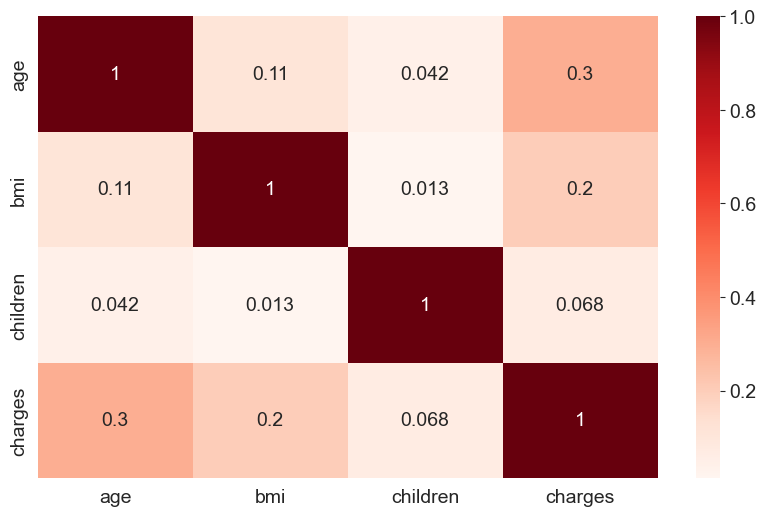

In [ ]:
sns.heatmap(data=df_onlyvalues.corr(),
            cmap='Reds',
            annot=True)

**Correlation vs causation fallacy:** Note that a high correlation cannot be used to interpret a cause-effect relationship between features. Two features $X$ and $Y$ can be correlated if $X$ causes $Y$ or if $Y$ causes $X$, or if both are caused independently by some other factor $Z$, and the correlation will no longer hold true if one of the cause-effect relationships is broken. It's also possible that $X$ are $Y$ simply appear to be correlated because the sample is too small. 

While this may seem obvious, computers can't differentiate between correlation and causation, and decisions based on automated system can often have major consequences on society, so it's important to study why automated systems lead to a given result. Determining cause-effect relationships requires human insight.

## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [ ]:
df_nonSmoker = df[df['smoker']=='no']
df_nonSmoker

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


Next, let's visualize the relationship between "age" and "charges"

<Axes: title={'center': 'Charges x Age'}, xlabel='age', ylabel='charges'>

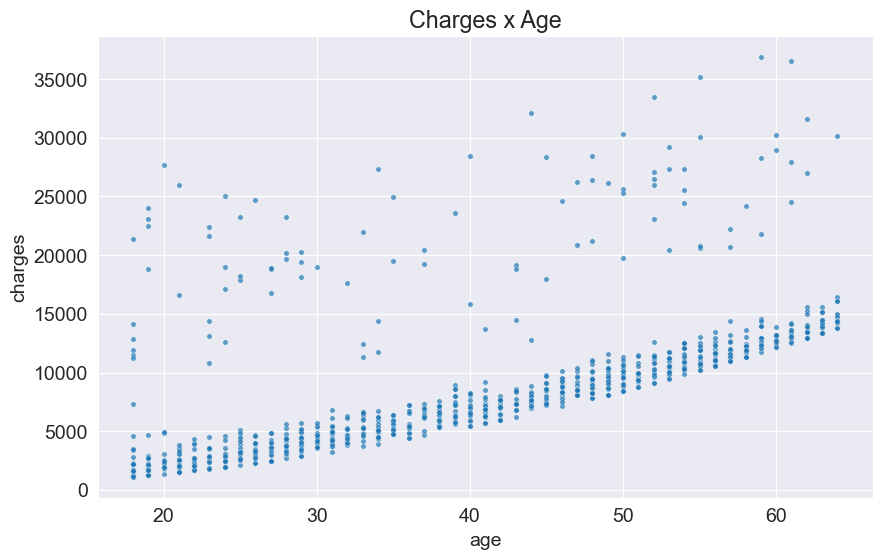

In [ ]:
plt.title('Charges x Age')
sns.scatterplot(data=df_nonSmoker,
                x='age',
                y='charges',
                alpha=0.7 , # Contraste da cor do azul
                s=15
                )       # Tamanho do scatter

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

$y = wx + b$

The line is characterized two numbers: $w$ (called "slope") and $b$ (called "intercept"). 

### Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

$charges = w \times age + b$

We'll try determine $w$ and $b$ for the line that best fits the data. 

* This technique is called _linear regression_, and we call the above equation a _linear regression model_, because it models the relationship between "age" and "charges" as a straight line. 

* The numbers $w$ and $b$ are called the _parameters_ or _weights_ of the model.

* The values in the "age" column of the dataset are called the _inputs_ to the model and the values in the charges column are called "targets". 

Let define a helper function `estimate_charges`, to compute $charges$, given $age$, $w$ and $b$.


In [ ]:
def estimate_charges(age, w, b):
    return w*age + b

In [ ]:
ages = df_nonSmoker.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [ ]:
# Lets just supose
w=50
b=100

In [ ]:
estimated_charges = estimate_charges(ages,w,b)

Text(0, 0.5, 'Estimate charges')

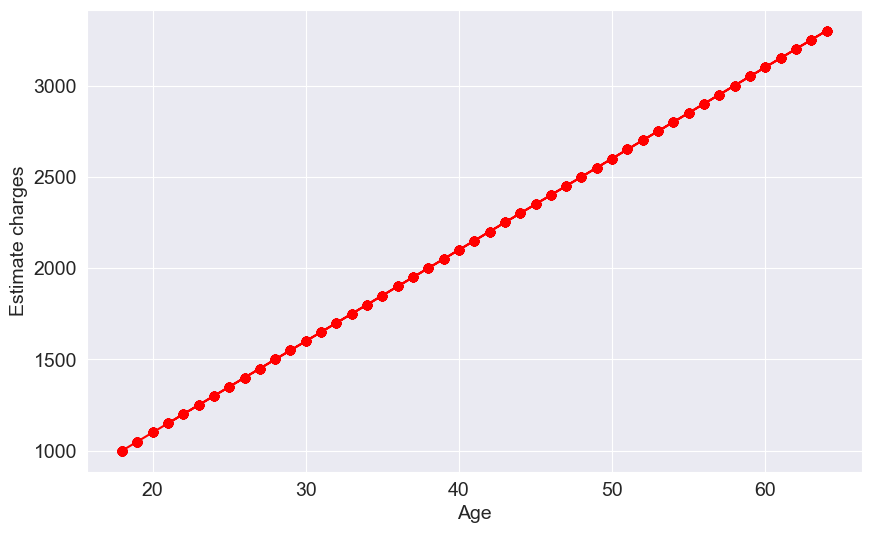

In [ ]:
plt.plot(ages, estimated_charges, 'r-o')
plt.xlabel('Age')
plt.ylabel('Estimate charges')

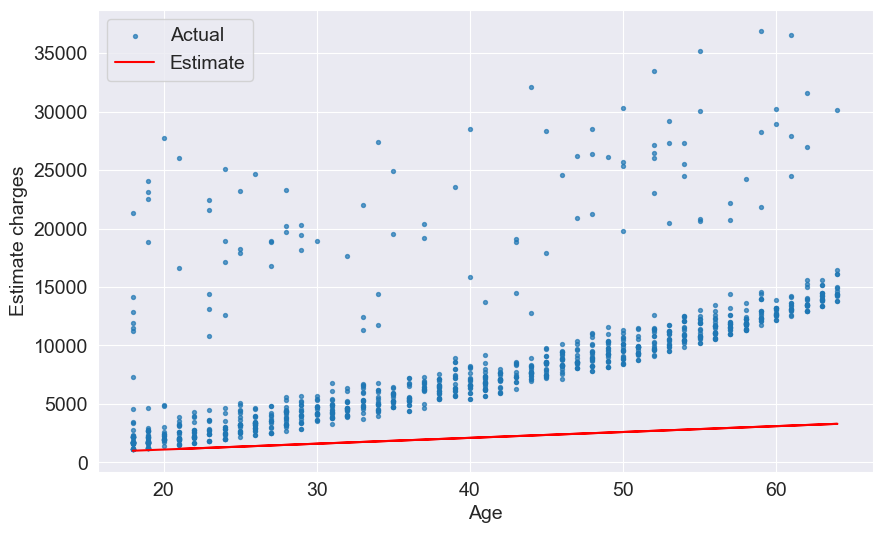

In [ ]:
plt.scatter(ages, df_nonSmoker.charges, s=8, alpha=0.7)
plt.plot(ages, estimated_charges, 'r')
plt.xlabel('Age')
plt.ylabel('Estimate charges')
plt.legend(['Actual', 'Estimate'])

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [ ]:
def try_parameters(w,b):
    ages = df_nonSmoker.age

    estimated_charges = estimate_charges(ages,w,b)

    plt.scatter(ages, df_nonSmoker.charges, s=8, alpha=0.7)
    plt.plot(ages, estimated_charges, 'r')
    plt.xlabel('Age')
    plt.ylabel('Estimate charges')
    plt.legend(['Actual', 'Estimate'])


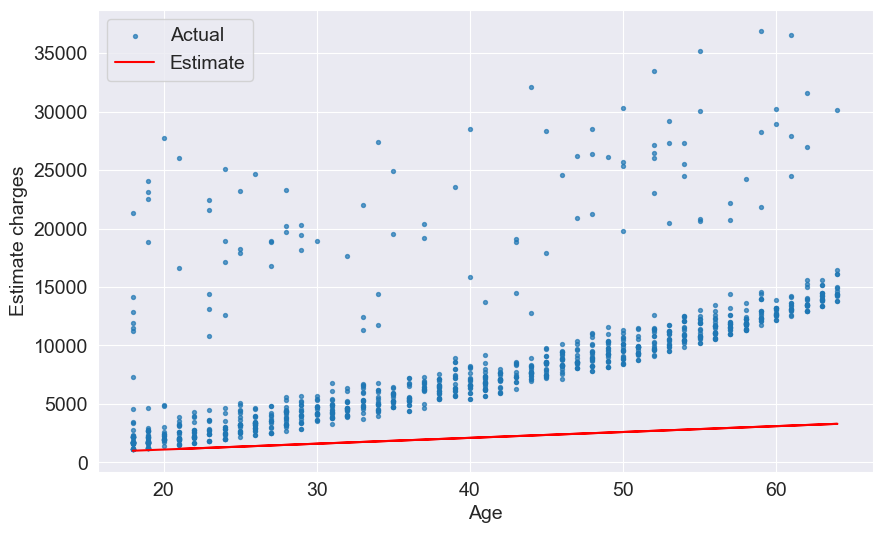

In [ ]:
try_parameters(50,100)

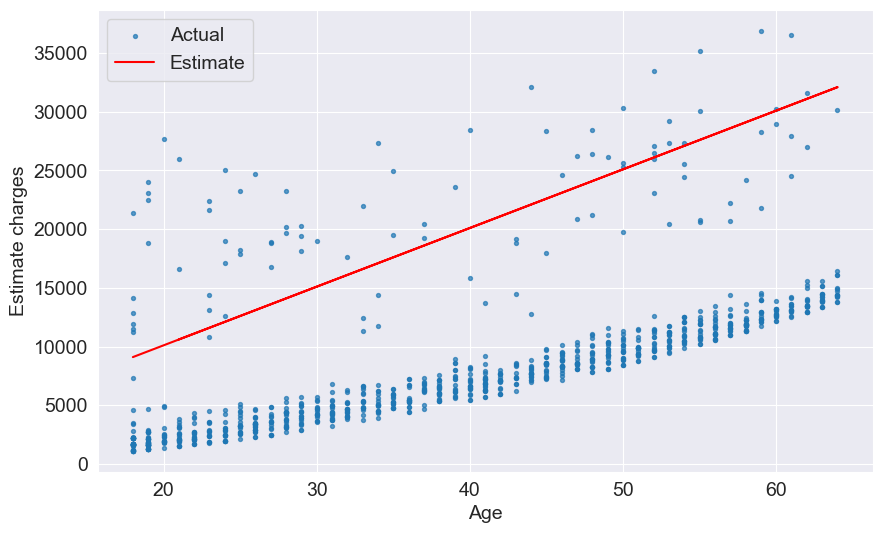

In [ ]:
try_parameters(500,100)

> **EXERCISE**: Try various values of $w$ and $b$ to find a line that best fits the data. What is the effect of changing the value of $w$? What is the effect of changing $b$?

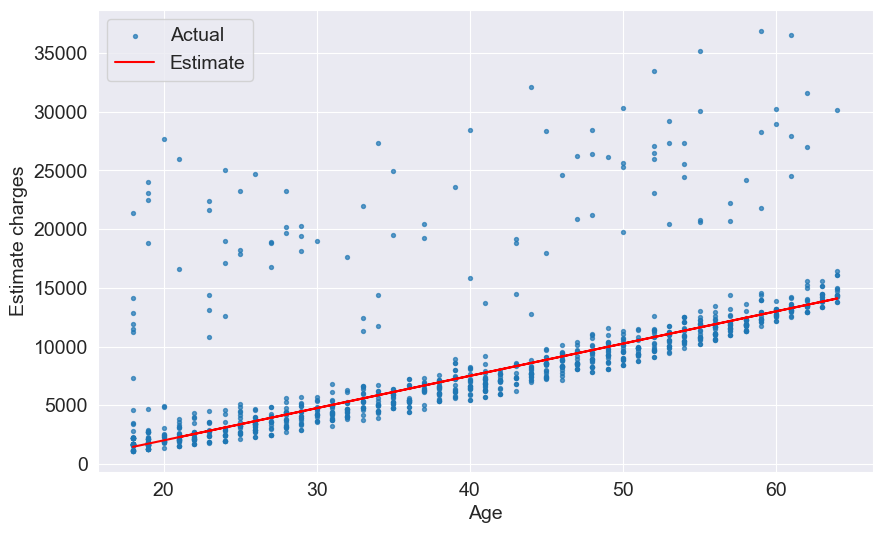

In [ ]:
try_parameters(275,-3500)

As we change the values, of $w$ and $b$ manually, trying to move the line visually closer to the points, we are _learning_ the approximate relationship between "age" and "charges". 

Wouldn't it be nice if a computer could try several different values of `w` and `b` and _learn_ the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.

2. Once the "measure of fit" has been computed, we need a way to modify `w` and `b` to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine `w` and `b` for the best fit line, starting from a random guess.

### Loss/Cost Function

We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result

The result is a single number, known as the **root mean squared error** (RMSE). The above description can be stated mathematically as follows: 

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Geometrically, the residuals can be visualized as follows:

<img src="https://i.imgur.com/ll3NL80.png" width="420">

Let's define a function to compute the RMSE.

In [ ]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(predictions-targets)))

In [ ]:
target = df_nonSmoker.charges
predicted = estimate_charges(ages, 50, 100)

In [ ]:
print(f'{rmse(target, predicted):.2f}')

8461.95


Here's how we can interpret the above number: *On average, each element in the prediction differs from the actual target by \\$8461*. 

The result is called the *loss* because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the `try_parameters` functions to also display the loss.

In [ ]:
def try_parameters(w1,b1):
    ages = df_nonSmoker.age
    target = df_nonSmoker.charges
    predicted = estimate_charges(ages, w1, b1)
    estimated_charges1 = estimate_charges(ages,w1,b1)

    plt.scatter(ages, target, s=8, alpha=0.7)
    plt.plot(ages, estimated_charges1, 'r')
    plt.xlabel('Age')
    plt.ylabel('Estimate charges')
    plt.legend(['Actual', 'Estimate'])
    loss = rmse(target, predicted)
    print(f' RMSE Loss: {loss:.2f}')

 RMSE Loss: 8461.95


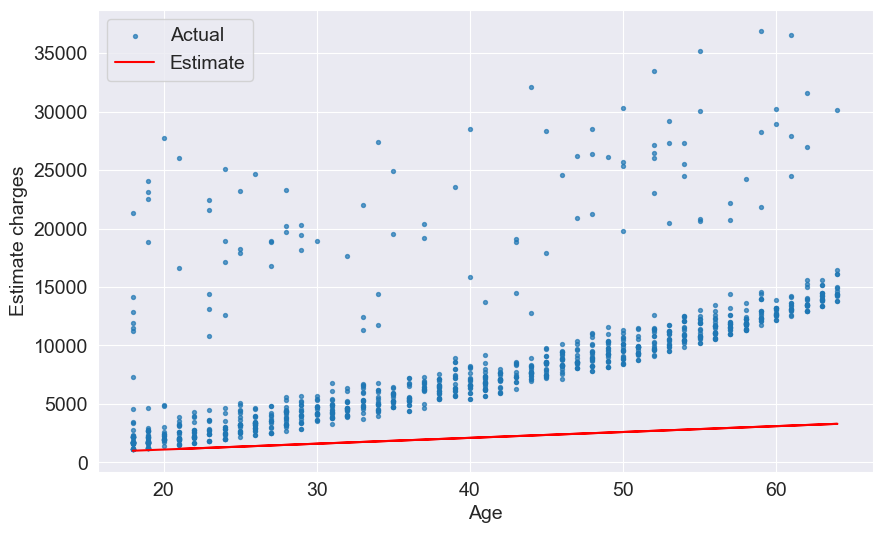

In [ ]:
try_parameters(50,100)

> **EXERCISE**: Try different values of $w$ and $b$ to minimize the RMSE loss. What's the lowest value of loss you are able to achieve? Can you come with a general strategy for finding better values of $w$ and $b$ by trial and error?

 RMSE Loss: 4710.71


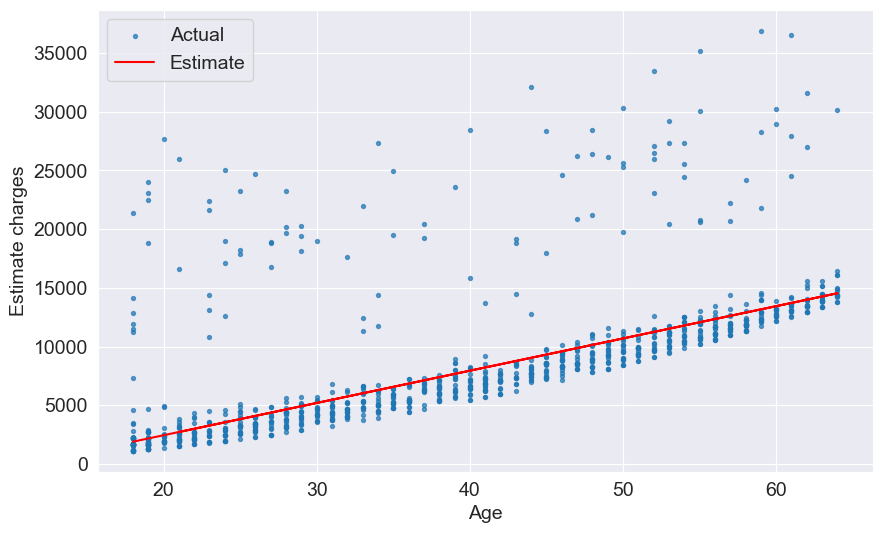

In [ ]:
try_parameters(275,-3060)

### Optimizer

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data.

* Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
* Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for `w` and `b` using matrix operations, while gradient descent uses a iterative approach, starting with a random values of `w` and `b` and slowly improving them using derivatives. 

Here's a visualization of how gradient descent works:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)

Doesn't it look similar to our own strategy of gradually moving the line closer to the points?



### Linear Regression using Scikit-learn

In practice, you'll never need to implement either of the above methods yourself. You can use a library like `scikit-learn` to do this for you. 

In [ ]:
from sklearn.linear_model import LinearRegression

First, we create a new model object.

In [ ]:
model = LinearRegression()

Next, we can use the `fit` method of the model to find the best fit line for the inputs and targets.

In [ ]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



Not that the input `X` must be a 2-d array, so we'll need to pass a dataframe, instead of a single column.

In [ ]:
inputs = df_nonSmoker[['age']]
targets = df_nonSmoker.charges

print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


Let's fit the model to the data.

In [ ]:
model.fit(inputs, targets)

LinearRegression()

We can now make predictions using the model. Let's try predicting the charges for the ages 23, 37 and 61

In [ ]:
model.predict(np.array([[23],[37],[61]]))

c:\Users\Davi\miniconda3\envs\tf-env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [ ]:
model.predict(np.array([[23]]))

c:\Users\Davi\miniconda3\envs\tf-env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([4055.30443855])

Do these values seem reasonable? Compare them with the scatter plot above.

Let compute the predictions for the entire set of inputs

In [ ]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
pd.DataFrame(predictions)

,0
0,2719.059874
1,5391.549003
2,6727.793567
3,6460.544654
4,6193.295741
...,...
1059,11805.522911
1060,11271.025085
1061,2719.059874
1062,2719.059874


Let's compute the RMSE loss to evaluate the model.

In [ ]:
rmse(targets, predictions)

np.float64(4662.505766636395)

Seems like our prediction is off by $4000 on average, which is not too bad considering the fact that there are several outliers.

The parameters of the model are stored in the `coef_` and `intercept_` properties.

In [ ]:
# w
model.coef_

array([267.24891283])

In [ ]:
# b
model.intercept_

np.float64(-2091.4205565650827)

 RMSE Loss: 4662.51


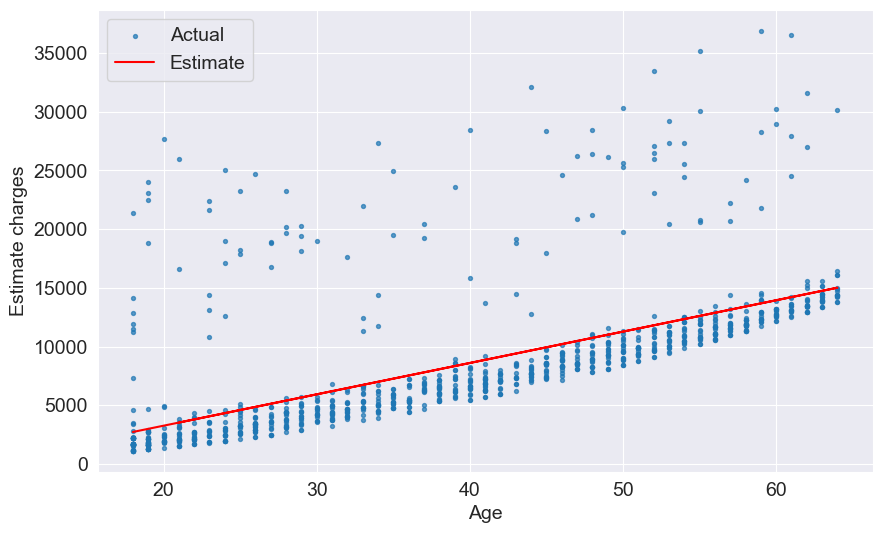

In [ ]:
try_parameters(model.coef_, model.intercept_)

Indeed the line is quite close to the points. It is slightly above the cluster of points, because it's also trying to account for the outliers. 

> **EXERCISE**: Use the [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) class from `scikit-learn` to train a model using the stochastic gradient descent technique. Make predictions and compute the loss. Do you see any difference in the result?

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
SGDRegressor(model.coef_)

SGDRegressor(loss=array([267.24891283]))

In [ ]:
SGDRegressor(model.intercept_)

SGDRegressor(loss=np.float64(-2091.4205565650827))

In [ ]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# 1. Carregar os dados
df = pd.read_csv("medical.csv")

# 2. Criar a coluna 'non_smoker' (1 = não fuma, 0 = fuma)
df['non_smoker'] = df['smoker'].apply(lambda x: 1 if x == 'no' else 0)

# 3. Separar variáveis independentes e dependente
X = df[['non_smoker']]
y = df['charges']

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Padronizar os dados (opcional aqui, mas bom para prática com SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Treinar modelo SGDRegressor
model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Predizer e avaliar
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

# 8. Mostrar resultados
print(f"Coeficiente (impacto de ser não fumante): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_[0]:.2f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

# Gerar pontos previstos para os dois grupos (0 e 1)
X_plot = pd.DataFrame({'non_smoker': [0, 1]})
X_plot_scaled = scaler.transform(X_plot)
y_pred_line = model.predict(X_plot_scaled)

# Gráfico interativo com os dados reais
fig = px.strip(df, x="non_smoker", y="charges", color="non_smoker",
               title="Charges vs Non-Smoker (with SGD Regression Line)",
               labels={"non_smoker": "Non-Smoker (0 = yes, 1 = no)", "charges": "Medical Charges"})

# Adiciona linha de regressão aprendida
fig.add_trace(go.Scatter(x=[0, 1], y=y_pred_line, mode='lines+markers',
                         name="SGD Regression Line", line=dict(color='black', dash='dash')))

fig.update_layout(showlegend=True)
fig.show()

Coeficiente (impacto de ser não fumante): -9352.73
Intercepto: 13381.07
Erro Quadrático Médio (MSE): 52799741.98


In [ ]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Carregar dados
df = pd.read_csv("medical.csv")
df['non_smoker'] = df['smoker'].apply(lambda x: 1 if x == 'no' else 0)
X = df[['non_smoker']]
y = df['charges']

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Modelo SEM padronização ===
model_raw = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
mse_raw = mean_squared_error(y_test, y_pred_raw)

# === Modelo COM padronização ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)

# === Comparação ===
print("Modelo SEM padronização:")
print(f"  Coeficiente: {model_raw.coef_[0]:.2f}")
print(f"  MSE: {mse_raw:.2f}\n")

print("Modelo COM padronização:")
print(f"  Coeficiente: {model_scaled.coef_[0]:.2f}")
print(f"  MSE: {mse_scaled:.2f}")


Modelo SEM padronização:
  Coeficiente: -22933.62
  MSE: 52937340.89

Modelo COM padronização:
  Coeficiente: -9352.73
  MSE: 52799741.98


In [ ]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 1. Carregar e filtrar apenas fumantes
df = pd.read_csv("medical.csv")
df_smokers = df[df['smoker'] == 'no']

# 2. Selecionar features e target
features = ['age', 'bmi', 'children']    # você pode incluir mais se quiser
X = df_smokers[features]
y = df_smokers['charges']

# 3. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Padronizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treinar o modelo
model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Avaliar
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

# 7. Resultados
print("Coeficientes:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercepto: {model.intercept_[0]:.2f}")
print(f"MSE: {mse:.2f}")


Coeficientes:
  age: 3660.31
  bmi: 137.74
  children: 703.23
Intercepto: 8494.97
MSE: 19277067.71


In [ ]:
# Plot para cada variável individual
for i, feature in enumerate(features):
    # Scatter com linha de regressão estimada pelo modelo
    x_vals = df_smokers[feature]
    x_scaled = scaler.transform(df_smokers[features])[:, i]
    y_pred = model.intercept_[0] + x_scaled * model.coef_[i]

    fig = px.scatter(df_smokers, x=feature, y='charges',
                     title=f"Charges vs {feature.capitalize()} (Smokers Only)",
                     opacity=0.6)

    fig.add_scatter(x=x_vals, y=y_pred, mode='lines', name='SGD Regression Line',
                    line=dict(color='black', dash='dash'))

    fig.show()

### Machine Learning

Congratulations, you've just trained your first _machine learning model!_ Machine learning is simply the process of computing the best parameters to model the relationship between some feature and targets. 

Every machine learning problem has three components:

1. **Model**

2. **Cost Function**

3. **Optimizer**

We'll look at several examples of each of the above in future tutorials. Here's how the relationship between these three components can be visualized:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

As we've seen above, it takes just a few lines of code to train a machine learning model using `scikit-learn`.

In [ ]:
# Create inputs and targets
inputs, targets = df_nonSmoker[['age']], df_nonSmoker['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print(f'Loss: {loss:.2f}')

Loss: 4662.51


## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$

We need to change just one line of code to include the BMI.

In [ ]:
# Create inputs and targets
inputs, targets = df_nonSmoker[['age', 'bmi']], df_nonSmoker['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print(f'Loss: {loss:.2f}')

Loss: 4662.31


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [ ]:
df_nonSmoker.charges.corr(df_nonSmoker.bmi)

np.float64(0.08403654312833271)

In [ ]:
fig = px.scatter(data_frame=df_nonSmoker,
           y='charges',
           x='bmi',
           title='Charges x Bmi')
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.show()

In [ ]:
fig3d = px.scatter_3d(data_frame=df_nonSmoker,
           y='bmi',
           x='age',
           z='charges',
           title='Charges x Bmi x Age')
fig3d.update_traces(marker=dict(size=3, opacity=0.8))
fig3d.show()

You can see that it's harder to interpret a 3D scatter plot compared to a 2D scatter plot. As we add more features, it becomes impossible to visualize all feature at once, which is why we use measures like correlation and loss. 

Let's also check the parameters of the model.

In [ ]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488672))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply. 

> **EXERCISE**: Train a linear regression model to estimate charges using BMI alone. Do you expect it to be better or worse than the previously trained models?

In [ ]:
inputs, targets = df_nonSmoker[['bmi']], df_nonSmoker['charges']

model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'Loss: {loss:.2f}')

df_nonSmoker.charges.corr(df_nonSmoker.bmi)

Loss: 5969.77


np.float64(0.08403654312833271)

In [ ]:
model.coef_, model.intercept_

(array([83.35055766]), np.float64(5879.424081872976))